In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [6]:
# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


In [7]:
# Machine Learning Libraries
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

In [8]:
# Visualization Libraries
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import wordcloud
from wordcloud import WordCloud

In [9]:
# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jatin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jatin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jatin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\jatin\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# 1. DATA LOADING AND EXPLORATION

In [10]:
import pandas as pd

def load_data(file_path):
    """
    Load social media data from CSV, JSON, or Excel formats,
    convert date column, and ensure a 'topic' column exists.
    """
    try:
        # Load based on file extension
        if file_path.endswith('.csv'):
            df = pd.read_csv(file_path, encoding='latin-1', header=None)
            # Special case: Sentiment140 has no header
            df.columns = ['target', 'ids', 'date', 'flag', 'user', 'text']
        elif file_path.endswith('.json'):
            df = pd.read_json(file_path)
        elif file_path.endswith(('.xlsx', '.xls')):
            df = pd.read_excel(file_path)
        else:
            raise ValueError("Unsupported file format. Please use CSV, JSON, or Excel files.")
        
        print(f"✅ Data loaded successfully! Shape: {df.shape}")
        
        # Convert 'date' column to datetime if present
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'], errors='coerce')
            print("📅 'date' column converted to datetime format.")
        
        # Add 'topic' column if missing
        if 'topic' not in df.columns:
            print("🏷️  No 'topic' column found. Creating default topic...")
            df['topic'] = 'General'

        print("✅ Dataset is ready for analysis!")
        return df

    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return None


In [11]:
# Set  dataset path
file_path = r'D:\dataset\training.1600000.processed.noemoticon.csv'

# Load the data
df = load_data(file_path)

#  Display first few rows
if df is not None:
    display(df.head())


✅ Data loaded successfully! Shape: (1600000, 6)
📅 'date' column converted to datetime format.
🏷️  No 'topic' column found. Creating default topic...
✅ Dataset is ready for analysis!


,target,ids,date,flag,user,text,topic
0,0,1467810369,2009-04-06 22:19:45,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",General
1,0,1467810672,2009-04-06 22:19:49,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,General
2,0,1467810917,2009-04-06 22:19:53,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,General
3,0,1467811184,2009-04-06 22:19:57,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,General
4,0,1467811193,2009-04-06 22:19:57,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",General


# 2. DATA PREPROCESSING

In [12]:
class TextPreprocessor:
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()
    
    def clean_text(self, text):
        """Clean and preprocess text data"""
        if pd.isna(text):
            return ""
        
        # Convert to lowercase
        text = text.lower()
        
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        
        # Remove user mentions and hashtags
        text = re.sub(r'@\w+|#\w+', '', text)
        
        # Remove punctuation and numbers
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        
        # Remove extra whitespace
        text = ' '.join(text.split())
        
        return text
    
    def remove_stopwords(self, text):
        """Remove stopwords from text"""
        tokens = word_tokenize(text)
        filtered_tokens = [word for word in tokens if word not in self.stop_words]
        return ' '.join(filtered_tokens)
    
    def lemmatize_text(self, text):
        """Lemmatize text"""
        tokens = word_tokenize(text)
        lemmatized_tokens = [self.lemmatizer.lemmatize(word) for word in tokens]
        return ' '.join(lemmatized_tokens)
    
    def preprocess_text(self, text):
        """Complete preprocessing pipeline"""
        text = self.clean_text(text)
        text = self.remove_stopwords(text)
        text = self.lemmatize_text(text)
        return text

# Initialize preprocessor
preprocessor = TextPreprocessor()

# Apply preprocessing
df['cleaned_text'] = df['text'].apply(preprocessor.preprocess_text)
print("Text preprocessing completed!")
print("\nExample of original vs cleaned text:")
for i in range(3):
    print(f"Original: {df.iloc[i]['text']}")
    print(f"Cleaned: {df.iloc[i]['cleaned_text']}")
    print("-" * 50)

Text preprocessing completed!

Example of original vs cleaned text:
Original: @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D
Cleaned: thats bummer shoulda got david carr third day
--------------------------------------------------
Original: is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!
Cleaned: upset cant update facebook texting might cry result school today also blah
--------------------------------------------------
Original: @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds
Cleaned: dived many time ball managed save rest go bound
--------------------------------------------------


# 3. SENTIMENT ANALYSIS

In [13]:
class SentimentAnalyzer:
    def __init__(self):
        self.vader_analyzer = SentimentIntensityAnalyzer()
    
    def get_textblob_sentiment(self, text):
        """Get sentiment using TextBlob"""
        blob = TextBlob(text)
        polarity = blob.sentiment.polarity
        
        if polarity > 0.1:
            return 'positive', polarity
        elif polarity < -0.1:
            return 'negative', polarity
        else:
            return 'neutral', polarity
    
    def get_vader_sentiment(self, text):
        """Get sentiment using VADER"""
        scores = self.vader_analyzer.polarity_scores(text)
        compound_score = scores['compound']
        
        if compound_score >= 0.05:
            return 'positive', compound_score
        elif compound_score <= -0.05:
            return 'negative', compound_score
        else:
            return 'neutral', compound_score
    
    def analyze_sentiment(self, df, text_column='cleaned_text'):
        """Analyze sentiment using multiple methods"""
        # TextBlob analysis
        textblob_results = df[text_column].apply(self.get_textblob_sentiment)
        df['textblob_sentiment'] = [result[0] for result in textblob_results]
        df['textblob_score'] = [result[1] for result in textblob_results]
        
        # VADER analysis
        vader_results = df[text_column].apply(self.get_vader_sentiment)
        df['vader_sentiment'] = [result[0] for result in vader_results]
        df['vader_score'] = [result[1] for result in vader_results]
        
        return df

# Initialize sentiment analyzer
sentiment_analyzer = SentimentAnalyzer()

# Analyze sentiment
df = sentiment_analyzer.analyze_sentiment(df)
print("Sentiment analysis completed!")
print("\nSentiment distribution (TextBlob):")
print(df['textblob_sentiment'].value_counts())
print("\nSentiment distribution (VADER):")
print(df['vader_sentiment'].value_counts())


Sentiment analysis completed!

Sentiment distribution (TextBlob):
textblob_sentiment
neutral     731762
positive    599421
negative    268817
Name: count, dtype: int64

Sentiment distribution (VADER):
vader_sentiment
positive    768430
neutral     446668
negative    384902
Name: count, dtype: int64


# 4. SENTIMENT VISUALIZATION

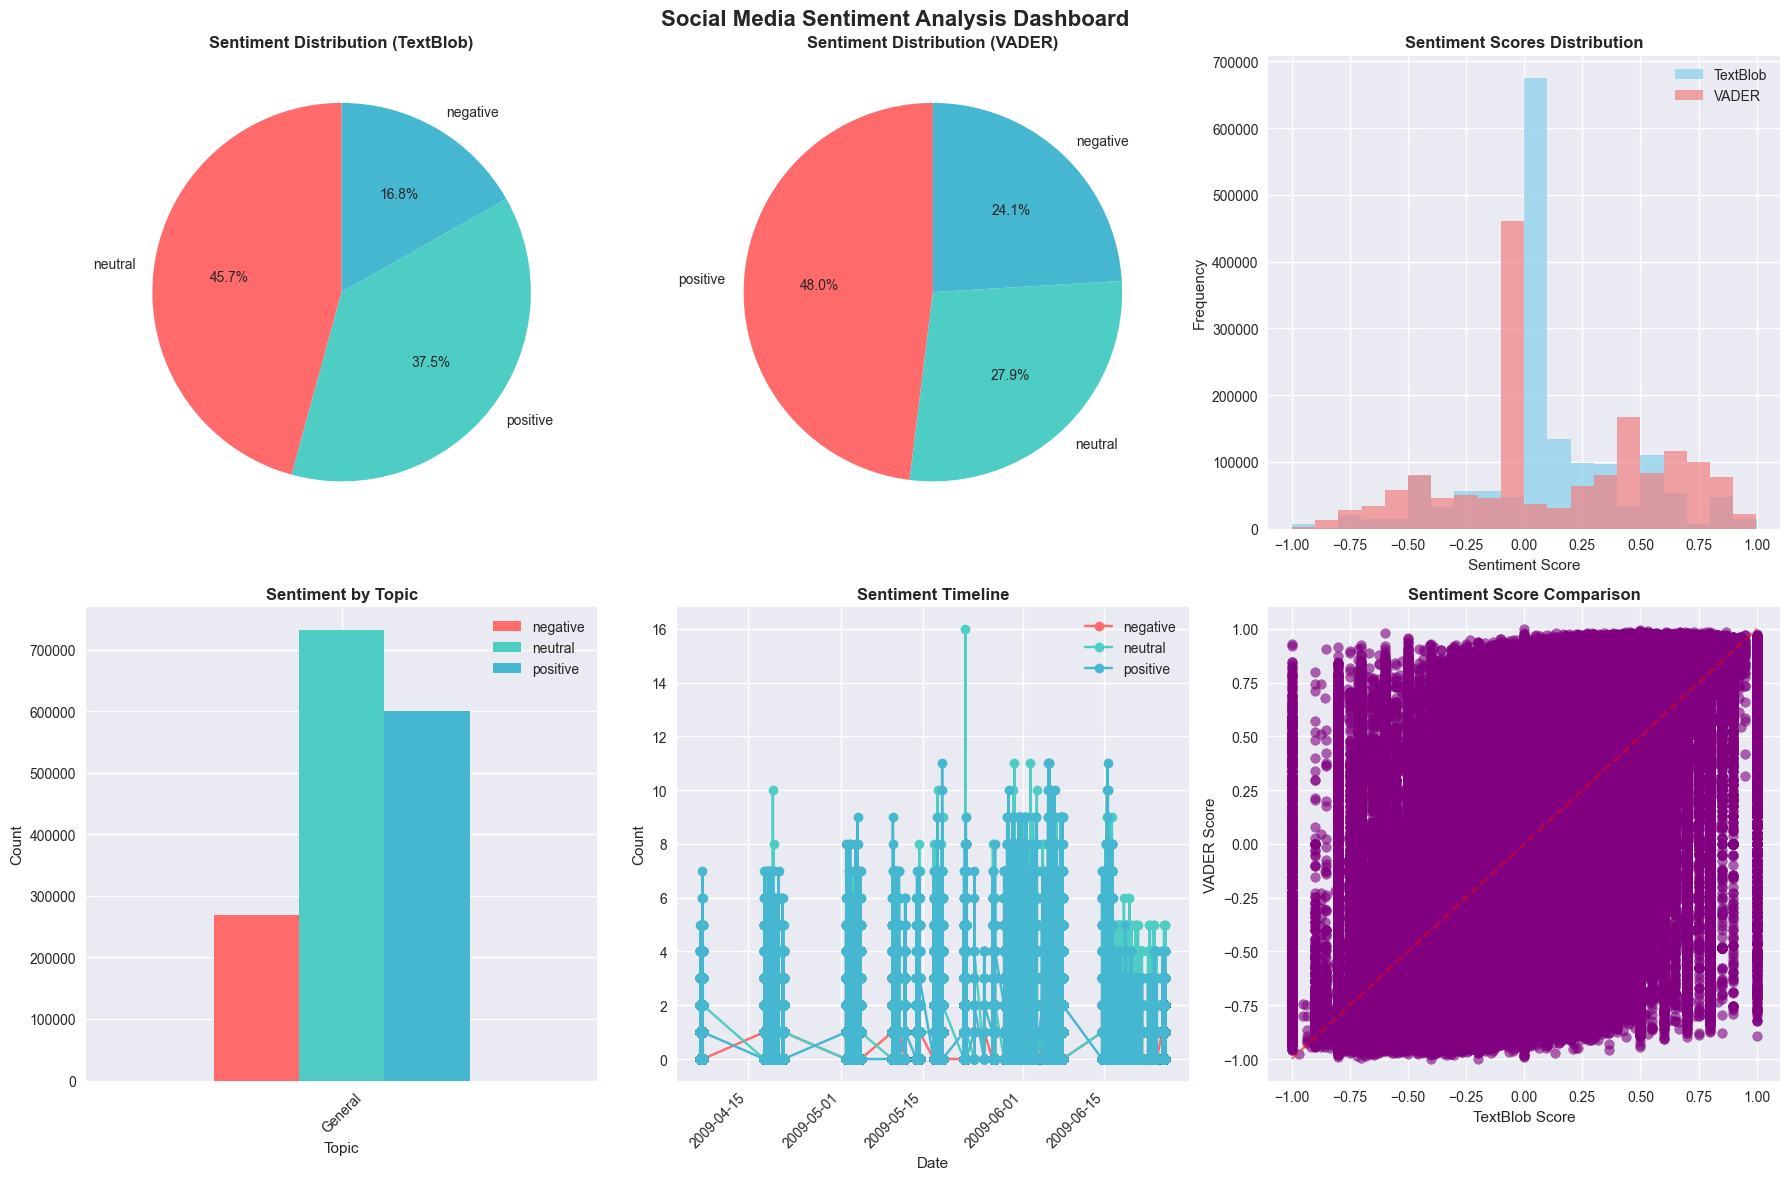

In [14]:
def create_sentiment_visualizations(df):
    """Create comprehensive sentiment visualizations"""
    
    # Set up the plotting style
    plt.style.use('seaborn-v0_8')
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Social Media Sentiment Analysis Dashboard', fontsize=16, fontweight='bold')
    
    # 1. Sentiment Distribution (TextBlob)
    sentiment_counts = df['textblob_sentiment'].value_counts()
    colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
    axes[0, 0].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
                   colors=colors, startangle=90)
    axes[0, 0].set_title('Sentiment Distribution (TextBlob)', fontweight='bold')
    
    # 2. Sentiment Distribution (VADER)
    vader_counts = df['vader_sentiment'].value_counts()
    axes[0, 1].pie(vader_counts.values, labels=vader_counts.index, autopct='%1.1f%%', 
                   colors=colors, startangle=90)
    axes[0, 1].set_title('Sentiment Distribution (VADER)', fontweight='bold')
    
    # 3. Sentiment Scores Distribution
    axes[0, 2].hist(df['textblob_score'], bins=20, alpha=0.7, color='skyblue', label='TextBlob')
    axes[0, 2].hist(df['vader_score'], bins=20, alpha=0.7, color='lightcoral', label='VADER')
    axes[0, 2].set_xlabel('Sentiment Score')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].set_title('Sentiment Scores Distribution', fontweight='bold')
    axes[0, 2].legend()
    
    # 4. Sentiment by Topic
    topic_sentiment = df.groupby(['topic', 'textblob_sentiment']).size().unstack(fill_value=0)
    topic_sentiment.plot(kind='bar', ax=axes[1, 0], color=colors)
    axes[1, 0].set_title('Sentiment by Topic', fontweight='bold')
    axes[1, 0].set_xlabel('Topic')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].legend()
    
    # 5. Sentiment Timeline
    df_timeline = df.groupby(['date', 'textblob_sentiment']).size().unstack(fill_value=0)
    df_timeline.plot(ax=axes[1, 1], color=colors, marker='o')
    axes[1, 1].set_title('Sentiment Timeline', fontweight='bold')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].legend()
    
    # 6. Sentiment Score Comparison
    comparison_data = df[['textblob_score', 'vader_score']]
    axes[1, 2].scatter(comparison_data['textblob_score'], comparison_data['vader_score'], 
                       alpha=0.6, color='purple')
    axes[1, 2].set_xlabel('TextBlob Score')
    axes[1, 2].set_ylabel('VADER Score')
    axes[1, 2].set_title('Sentiment Score Comparison', fontweight='bold')
    axes[1, 2].plot([-1, 1], [-1, 1], 'r--', alpha=0.5)  # Diagonal line
    
    plt.tight_layout()
    plt.show()
# Create visualizations
create_sentiment_visualizations(df)

# 5. ADVANCED ANALYTICS

In [15]:
def generate_sentiment_insights(df):
    """Generate detailed insights from sentiment analysis"""
    
    print("=" * 60)
    print("SENTIMENT ANALYSIS INSIGHTS")
    print("=" * 60)
    
    # Overall sentiment statistics
    total_posts = len(df)
    positive_posts = len(df[df['textblob_sentiment'] == 'positive'])
    negative_posts = len(df[df['textblob_sentiment'] == 'negative'])
    neutral_posts = len(df[df['textblob_sentiment'] == 'neutral'])
    
    print(f"\n📊 OVERALL STATISTICS:")
    print(f"Total Posts Analyzed: {total_posts}")
    print(f"Positive Posts: {positive_posts} ({positive_posts/total_posts*100:.1f}%)")
    print(f"Negative Posts: {negative_posts} ({negative_posts/total_posts*100:.1f}%)")
    print(f"Neutral Posts: {neutral_posts} ({neutral_posts/total_posts*100:.1f}%)")
    
    # Sentiment by topic
    print(f"\n📈 SENTIMENT BY TOPIC:")
    topic_analysis = df.groupby('topic')['textblob_sentiment'].value_counts().unstack(fill_value=0)
    topic_analysis['total'] = topic_analysis.sum(axis=1)
    topic_analysis['positive_ratio'] = topic_analysis['positive'] / topic_analysis['total']
    topic_analysis = topic_analysis.sort_values('positive_ratio', ascending=False)
    
    for topic in topic_analysis.index:
        pos_ratio = topic_analysis.loc[topic, 'positive_ratio']
        total = topic_analysis.loc[topic, 'total']
        print(f"  {topic}: {pos_ratio:.1%} positive ({total} total posts)")
    
    # Most positive and negative posts
    print(f"\n🎯 EXTREME SENTIMENTS:")
    most_positive = df.loc[df['textblob_score'].idxmax()]
    most_negative = df.loc[df['textblob_score'].idxmin()]
    
    print(f"Most Positive Post (Score: {most_positive['textblob_score']:.3f}):")
    print(f"  '{most_positive['text'][:100]}...'")
    print(f"Most Negative Post (Score: {most_negative['textblob_score']:.3f}):")
    print(f"  '{most_negative['text'][:100]}...'")
    
    # Correlation between methods
    correlation = df['textblob_score'].corr(df['vader_score'])
    print(f"\n🔗 METHOD CORRELATION:")
    print(f"TextBlob vs VADER correlation: {correlation:.3f}")
    
    return topic_analysis

# Generate insights
insights = generate_sentiment_insights(df)


SENTIMENT ANALYSIS INSIGHTS

📊 OVERALL STATISTICS:
Total Posts Analyzed: 1600000
Positive Posts: 599421 (37.5%)
Negative Posts: 268817 (16.8%)
Neutral Posts: 731762 (45.7%)

📈 SENTIMENT BY TOPIC:
  General: 37.5% positive (1600000 total posts)

🎯 EXTREME SENTIMENTS:
Most Positive Post (Score: 1.000):
  '@redvinylgirl my mom has it. I wish you the best of luck ...'
Most Negative Post (Score: -1.000):
  'I just saw that they found that Tracy girl in a piece of luggage... How fucking terrible ...'

🔗 METHOD CORRELATION:
TextBlob vs VADER correlation: 0.627


# 6. WORD CLOUD GENERATION

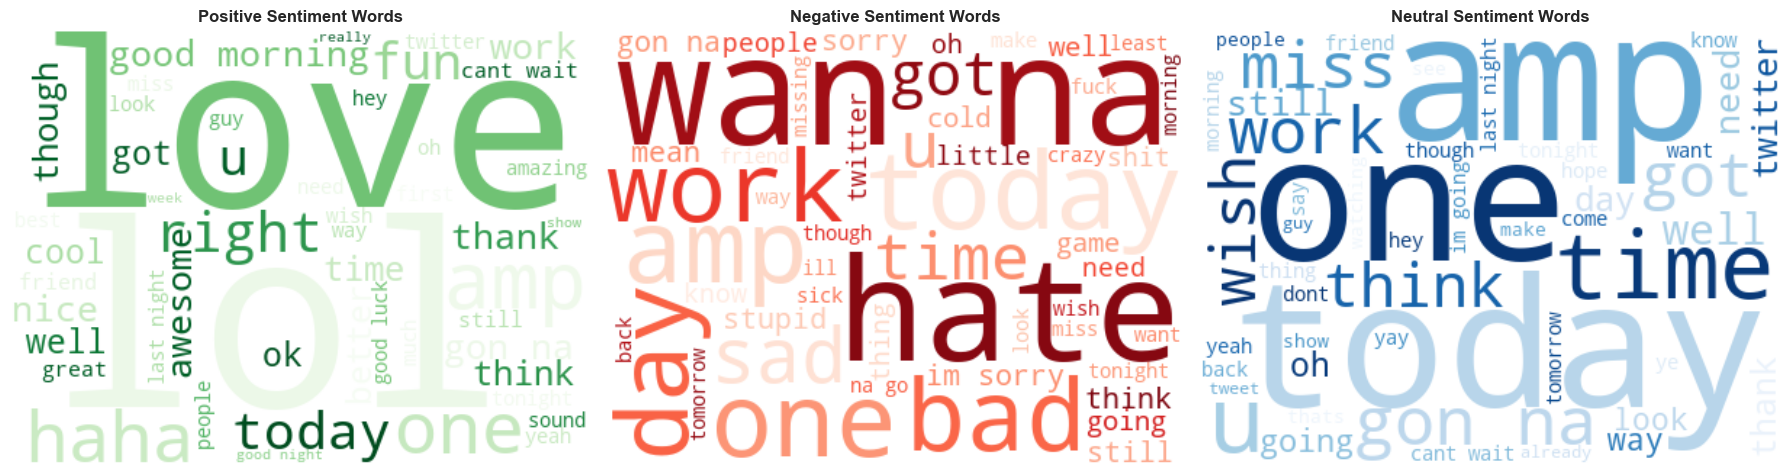

In [16]:
def create_sentiment_wordclouds(df):
    """Create word clouds for different sentiments"""
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    sentiments = ['positive', 'negative', 'neutral']
    colors = ['Greens', 'Reds', 'Blues']
    
    for i, sentiment in enumerate(sentiments):
        # Get text for this sentiment
        sentiment_text = ' '.join(df[df['textblob_sentiment'] == sentiment]['cleaned_text'])
        
        if sentiment_text.strip():  # Check if there's text to generate wordcloud
            wordcloud = WordCloud(width=400, height=300, 
                                background_color='white',
                                colormap=colors[i],
                                max_words=50).generate(sentiment_text)
            
            axes[i].imshow(wordcloud, interpolation='bilinear')
            axes[i].set_title(f'{sentiment.capitalize()} Sentiment Words', fontweight='bold')
        else:
            axes[i].text(0.5, 0.5, f'No {sentiment} posts found', 
                        transform=axes[i].transAxes, ha='center', va='center')
            axes[i].set_title(f'{sentiment.capitalize()} Sentiment Words', fontweight='bold')
        
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Create word clouds
create_sentiment_wordclouds(df)

# 7. TIME SERIES ANALYSIS

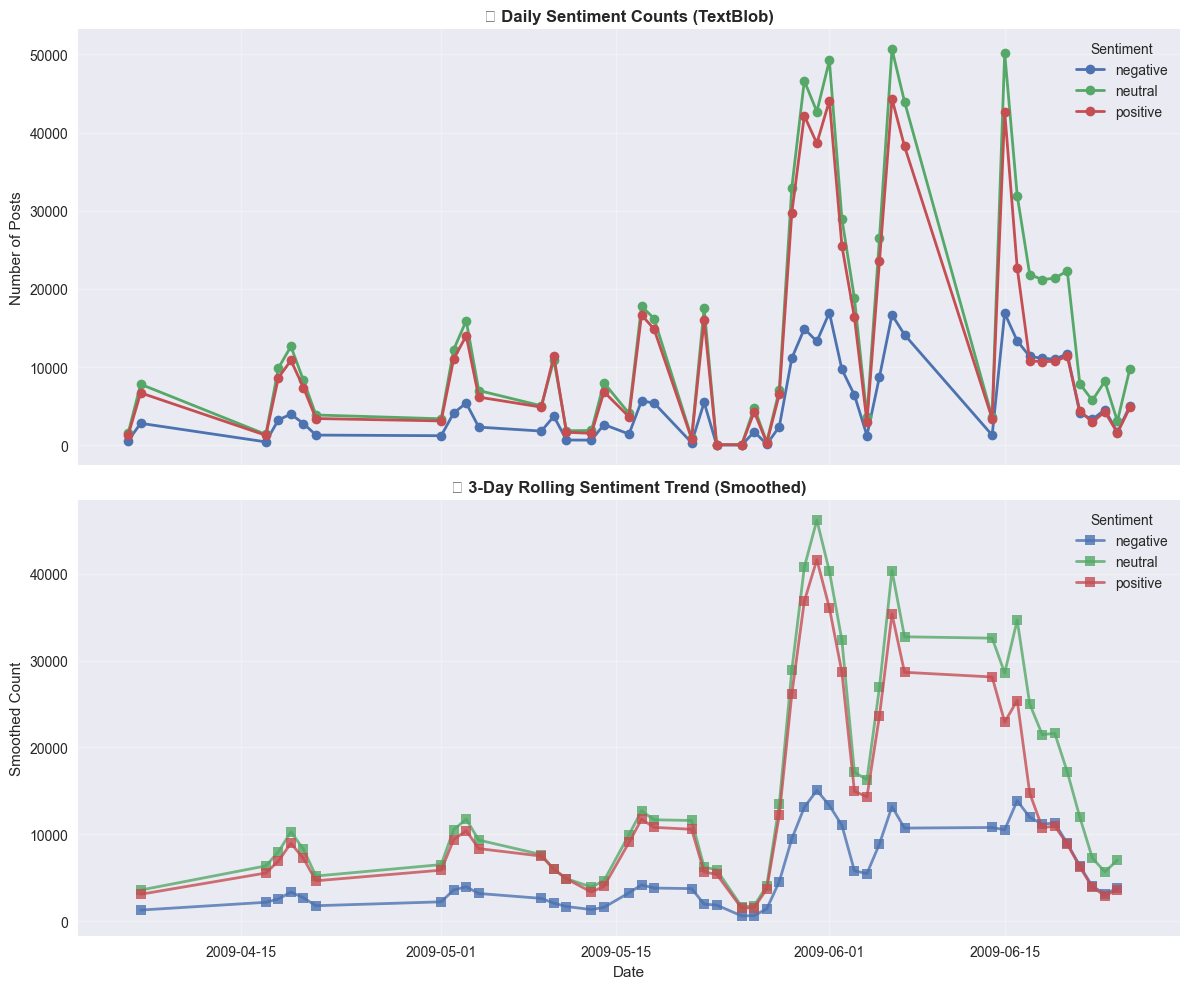


📊 SENTIMENT TREND SUMMARY:
→ Positive sentiment is increasing 📈 (avg Δ: 75.53 posts/day)
→ Negative sentiment is increasing 📈 (avg Δ: 95.62 posts/day)
→ Neutral sentiment is increasing 📈 (avg Δ: 176.38 posts/day)


In [17]:


def analyze_sentiment_trends(df):
    """Analyze sentiment trends over time (TextBlob)"""
    
    # Ensure 'date' is datetime
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date'])  # Remove rows with invalid dates
    
    # Group by date and sentiment
    daily_sentiment = df.groupby([df['date'].dt.date, 'textblob_sentiment']).size().unstack(fill_value=0)
    
    # Rolling average
    window = 3
    daily_sentiment_smooth = daily_sentiment.rolling(window=window, center=True).mean()
    
    # Plotting
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # 1. Raw sentiment counts
    daily_sentiment.plot(ax=axes[0], marker='o', linewidth=2)
    axes[0].set_title("📊 Daily Sentiment Counts (TextBlob)", fontweight='bold')
    axes[0].set_ylabel("Number of Posts")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(title="Sentiment")

    # 2. Smoothed trends
    daily_sentiment_smooth.plot(ax=axes[1], marker='s', linewidth=2, alpha=0.8)
    axes[1].set_title(f"📈 {window}-Day Rolling Sentiment Trend (Smoothed)", fontweight='bold')
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Smoothed Count")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(title="Sentiment")

    plt.tight_layout()
    plt.show()

    # Print basic trend direction
    print("\n📊 SENTIMENT TREND SUMMARY:")
    for sentiment in ['positive', 'negative', 'neutral']:
        if sentiment in daily_sentiment.columns:
            trend = daily_sentiment[sentiment].diff().mean()
            direction = "increasing 📈" if trend > 0 else "decreasing 📉" if trend < 0 else "stable ➖"
            print(f"→ {sentiment.capitalize()} sentiment is {direction} (avg Δ: {trend:.2f} posts/day)")

# Run trend analysis
analyze_sentiment_trends(df)


# 8. MACHINE LEARNING MODEL FOR SENTIMENT PREDICTION

In [18]:
def train_sentiment_model(df):
    """Train a machine learning model for sentiment prediction"""
    
    # ✅ All necessary imports inside the function (Jupyter-safe)
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import Pipeline
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.naive_bayes import MultinomialNB
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np

    print("\n✅ ENTERED train_sentiment_model FUNCTION")
    print("🤖 TRAINING SENTIMENT PREDICTION MODEL:")
    print("-" * 40)

    # Prepare data
    X = df['cleaned_text']
    y = df['textblob_sentiment']

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)

    # Define models
    models = {
        'Naive Bayes': Pipeline([
            ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
            ('classifier', MultinomialNB())
        ]),
        'Logistic Regression': Pipeline([
            ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
            ('classifier', LogisticRegression(random_state=42, max_iter=1000))
        ])
    }

    best_model = None
    best_score = 0
    best_model_name = None

    # Train and evaluate models
    for name, model_pipeline in models.items():
        print(f"\n🚀 Training {name}...")
        model_pipeline.fit(X_train, y_train)
        y_pred = model_pipeline.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)

        print(f"{name} Accuracy: {accuracy:.3f}")
        print(f"{name} Classification Report:\n")
        print(classification_report(y_test, y_pred))

        if accuracy > best_score:
            best_score = accuracy
            best_model = model_pipeline
            best_model_name = name

    print(f"\n🏆 Best Model: {best_model_name} (Accuracy: {best_score:.3f})")
    return best_model
print("🎬 Starting training...")
model = train_sentiment_model(df)
print("✅ Training complete!")


🎬 Starting training...

✅ ENTERED train_sentiment_model FUNCTION
🤖 TRAINING SENTIMENT PREDICTION MODEL:
----------------------------------------

🚀 Training Naive Bayes...
Naive Bayes Accuracy: 0.779
Naive Bayes Classification Report:

              precision    recall  f1-score   support

    negative       0.90      0.41      0.56     80645
     neutral       0.70      0.92      0.80    219529
    positive       0.89      0.77      0.83    179826

    accuracy                           0.78    480000
   macro avg       0.83      0.70      0.73    480000
weighted avg       0.81      0.78      0.77    480000


🚀 Training Logistic Regression...
Logistic Regression Accuracy: 0.912
Logistic Regression Classification Report:

              precision    recall  f1-score   support

    negative       0.91      0.82      0.86     80645
     neutral       0.89      0.94      0.91    219529
    positive       0.94      0.92      0.93    179826

    accuracy                           0.91    480

# 9. EXPORT RESULTS

In [19]:
def export_results(df, filename='sentiment_analysis_results.csv'):
    """Export sentiment analysis results"""
    
    # Select relevant columns for export
    export_df = df[['text', 'cleaned_text', 'topic', 'date', 
                   'textblob_sentiment', 'textblob_score',
                   'vader_sentiment', 'vader_score']].copy()
    
    # Add timestamp
    export_df['analysis_timestamp'] = datetime.now()
    
    # Save to CSV
    export_df.to_csv(filename, index=False)
    print(f"Results exported to {filename}")
    
    return export_df

# Export results
results_df = export_results(df)

print("\n" + "="*60)
print("SENTIMENT ANALYSIS COMPLETE!")
print("="*60)
print("\n🎉 Analysis Summary:")
print(f"✅ Processed {len(df)} social media posts")
print(f"✅ Applied text preprocessing and cleaning")
print(f"✅ Performed sentiment analysis using TextBlob and VADER")
print(f"✅ Generated comprehensive visualizations")
print(f"✅ Created word clouds for different sentiments")
print(f"✅ Analyzed sentiment trends over time")
print(f"✅ Exported results to CSV file")
print("\n📝 Next Steps:")
print("1. Load your own dataset using load_data('your_file.csv')")
print("2. Customize the preprocessing steps for your specific data")
print("3. Experiment with different sentiment analysis methods")
print("4. Use the trained model for real-time sentiment prediction")

Results exported to sentiment_analysis_results.csv

SENTIMENT ANALYSIS COMPLETE!

🎉 Analysis Summary:
✅ Processed 1600000 social media posts
✅ Applied text preprocessing and cleaning
✅ Performed sentiment analysis using TextBlob and VADER
✅ Generated comprehensive visualizations
✅ Created word clouds for different sentiments
✅ Analyzed sentiment trends over time
✅ Exported results to CSV file

📝 Next Steps:
1. Load your own dataset using load_data('your_file.csv')
2. Customize the preprocessing steps for your specific data
3. Experiment with different sentiment analysis methods
4. Use the trained model for real-time sentiment prediction


# 10. INTERACTIVE PLOTLY VISUALIZATIONS (BONUS)

In [ ]:
# 📦 Imports
import pandas as pd
import plotly.graph_objects as go

# 📊 Create and display interactive sentiment dashboard
def create_interactive_dashboard(df):
    """Create interactive Plotly dashboard for sentiment analysis"""

    # Ensure 'date' is datetime
    df['date'] = pd.to_datetime(df['date'])

    # ✅ PIE CHART: Sentiment Distribution (TextBlob)
    sentiment_counts = df['textblob_sentiment'].value_counts()
    fig1 = go.Figure(data=[go.Pie(
        labels=sentiment_counts.index,
        values=sentiment_counts.values,
        hole=0.3,
        hoverinfo='label+percent+value'
    )])
    fig1.update_layout(
        title="📊 Interactive Sentiment Distribution (TextBlob)",
        title_font_size=20
    )
    fig1.show()

    # ✅ TIMELINE: Sentiment Over Time
    timeline_data = df.groupby(['date', 'textblob_sentiment']).size().unstack(fill_value=0).reset_index()
    fig2 = go.Figure()
    for sentiment in ['positive', 'negative', 'neutral']:
        if sentiment in timeline_data.columns:
            fig2.add_trace(go.Scatter(
                x=timeline_data['date'],
                y=timeline_data[sentiment],
                mode='lines+markers',
                name=sentiment.capitalize()
            ))
    fig2.update_layout(
        title="📈 Sentiment Timeline (Daily Counts)",
        xaxis_title="Date",
        yaxis_title="Number of Posts",
        xaxis=dict(rangeslider=dict(visible=True)),
        title_font_size=20
    )
    fig2.show()

# 🚀 Run it (make sure df is already available and analyzed)
create_interactive_dashboard(df)
